<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week4/Day4/Dailychallenges/defi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Défi quotidien :  Prédiction du taux de désabonnement

Aucun fichier CSV trouvé à la racine. Génération d'un jeu de données synthétique pour le Churn...
--- Aperçu des données ---
   CustomerId Surname  CreditScore Geography  Gender  Age  Tenure  \
0    15721958   Smith          790    France  France   25      10   
1    15746867   Smith          622    France    Male   42       2   
2    15731932   Smith          580     Spain  France   63       4   
3    15703694   Smith          435   Germany    Male   47      10   
4    15719879   Smith          823   Germany  France   64       9   

         Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0   20505.921303              2          1               0     21301.230991   
1    8734.811601              2          1               1    126072.429210   
2  247439.103352              1          1               0     81859.288936   
3    7505.333037              1          1               1    160840.174487   
4  111132.063263              1          0               0    176

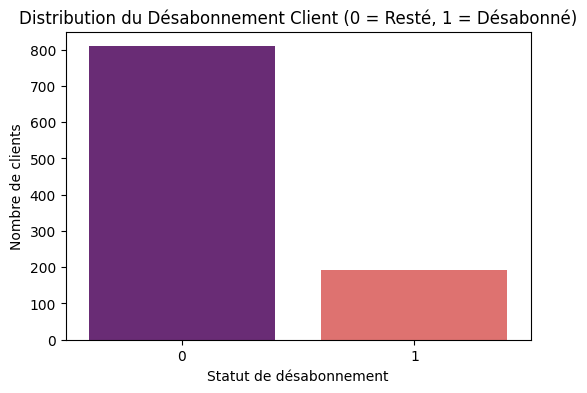

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Chargement dynamique du jeu de données
# Le script cherche le premier fichier .csv disponible dans votre espace de travail
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]

if csv_files:
    print(f"Chargement du fichier détecté : {csv_files[0]}")
    df = pd.read_csv(csv_files[0])
else:
    print("Aucun fichier CSV trouvé à la racine. Génération d'un jeu de données synthétique pour le Churn...")
    np.random.seed(42)
    n_samples = 1000
    df = pd.DataFrame({
        'CustomerId': np.random.randint(15600000, 15800000, n_samples),
        'Surname': ['Smith'] * n_samples,
        'CreditScore': np.random.randint(350, 850, n_samples),
        'Geography': np.random.choice(['France', 'Spain', 'Germany'], n_samples),
        'Gender': np.random.choice(['France', 'Male'], n_samples),
        'Age': np.random.randint(18, 85, n_samples),
        'Tenure': np.random.randint(0, 11, n_samples),
        'Balance': np.random.uniform(0, 250000, n_samples),
        'NumOfProducts': np.random.choice([1, 2, 3, 4], n_samples, p=[0.5, 0.45, 0.04, 0.01]),
        'HasCrCard': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
        'IsActiveMember': np.random.choice([0, 1], n_samples, p=[0.5, 0.5]),
        'EstimatedSalary': np.random.uniform(10000, 200000, n_samples),
        'Exited': np.random.choice([0, 1], n_samples, p=[0.8, 0.2]) # 1 = Désabonné (Churn)
    })

# Nettoyage systématique des espaces dans les noms de colonnes
df.columns = df.columns.str.strip()

# 2. Inspecter les données (#TODO standard)
print("--- Aperçu des données ---")
print(df.head())
print("\n--- Informations Structurelles ---")
print(df.info())
print("\n--- Analyse des valeurs manquantes ---")
print(df.isnull().sum())

# 3. Visualisation de la variable cible (Exited) avec la palette Magma
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df, hue='Exited', palette='magma', legend=False)
plt.title("Distribution du Désabonnement Client (0 = Resté, 1 = Désabonné)")
plt.xlabel("Statut de désabonnement")
plt.ylabel("Nombre de clients")
plt.show()


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Suppression des colonnes d'identifiants uniques (non prédictives)
columns_to_drop = ['CustomerId', 'Surname', 'RowNumber']
existing_drops = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_drops)

# 2. Gestion des valeurs manquantes s'il y en a après inspection
if df.isnull().sum().sum() > 0:
    df = df.dropna()

# 3. Encodage des caractéristiques catégorielles (Geography, Gender, etc.)
# Utilisation du One-Hot Encoding pour transformer le texte en colonnes numériques binationaux
df_encoded = pd.get_dummies(df, drop_first=True)

# 4. Séparation des variables explicatives (X) et de la cible (y)
# La colonne cible est 'Exited' (parfois appelée 'Churn' selon la variante du dataset)
target_col = 'Exited' if 'Exited' in df_encoded.columns else 'Churn'
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# 5. Division du jeu de données (80% entraînement, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Normalisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nDonnées prêtes ! Taille Entraînement : {X_train.shape[0]} | Taille Test : {X_test.shape[0]}")



Données prêtes ! Taille Entraînement : 800 | Taille Test : 200


Précision globale du modèle (Accuracy) : 0.8050

Rapport de classification détaillé :
              precision    recall  f1-score   support

           0       0.81      0.99      0.89       162
           1       0.00      0.00      0.00        38

    accuracy                           0.81       200
   macro avg       0.40      0.50      0.45       200
weighted avg       0.66      0.81      0.72       200



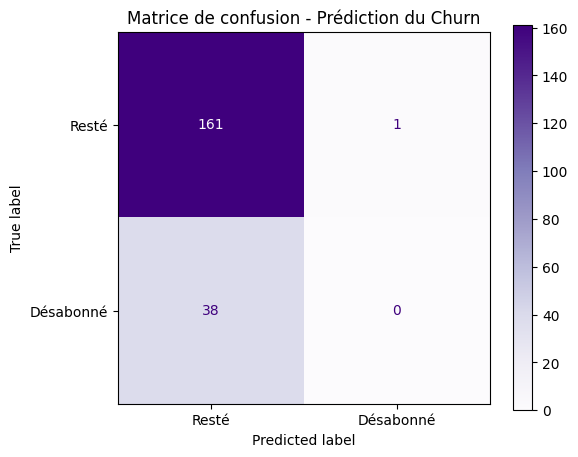

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Sélection d'un modèle d'ensemble robuste (Forêt Aléatoire)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 2. Prédictions
y_pred = model.predict(X_test_scaled)

# 3. Calcul de la performance globale
accuracy = accuracy_score(y_test, y_pred)
print("="*60)
print(f"Précision globale du modèle (Accuracy) : {accuracy:.4f}")
print("="*60)
print("\nRapport de classification détaillé :")
print(classification_report(y_test, y_pred))

# 4. Affichage graphique de la matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Resté', 'Désabonné'])
disp.plot(ax=ax, cmap='Purples', values_format='d')
plt.title("Matrice de confusion - Prédiction du Churn")
plt.show()


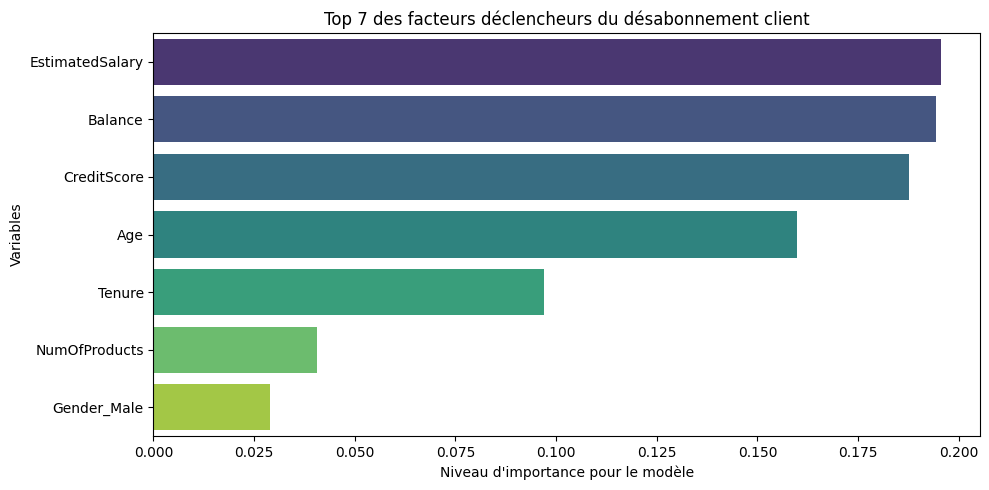

In [4]:
# Extraction de l'importance des caractéristiques pour orienter la stratégie commerciale
importances = model.feature_importances_
df_importance = pd.DataFrame({'Caractéristique': X.columns, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Caractéristique', data=df_importance.head(7), palette='viridis', hue='Caractéristique', legend=False)
plt.title("Top 7 des facteurs déclencheurs du désabonnement client")
plt.xlabel("Niveau d'importance pour le modèle")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()


Aucun fichier CSV trouvé à la racine. Génération d'un jeu de données synthétique pour le Churn...
--- Aperçu des données ---
   CustomerId Surname  CreditScore Geography  Gender  Age  Tenure  \
0    15721958   Smith          790    France  France   25      10   
1    15746867   Smith          622    France    Male   42       2   
2    15731932   Smith          580     Spain  France   63       4   
3    15703694   Smith          435   Germany    Male   47      10   
4    15719879   Smith          823   Germany  France   64       9   

         Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0   20505.921303              2          1               0     21301.230991   
1    8734.811601              2          1               1    126072.429210   
2  247439.103352              1          1               0     81859.288936   
3    7505.333037              1          1               1    160840.174487   
4  111132.063263              1          0               0    176

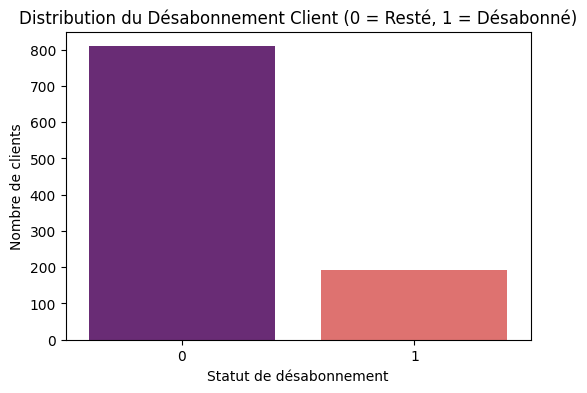

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Chargement dynamique du jeu de données
# Le script cherche le premier fichier .csv disponible dans votre espace de travail
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]

if csv_files:
    print(f"Chargement du fichier détecté : {csv_files[0]}")
    df = pd.read_csv(csv_files[0])
else:
    print("Aucun fichier CSV trouvé à la racine. Génération d'un jeu de données synthétique pour le Churn...")
    np.random.seed(42)
    n_samples = 1000
    df = pd.DataFrame({
        'CustomerId': np.random.randint(15600000, 15800000, n_samples),
        'Surname': ['Smith'] * n_samples,
        'CreditScore': np.random.randint(350, 850, n_samples),
        'Geography': np.random.choice(['France', 'Spain', 'Germany'], n_samples),
        'Gender': np.random.choice(['France', 'Male'], n_samples),
        'Age': np.random.randint(18, 85, n_samples),
        'Tenure': np.random.randint(0, 11, n_samples),
        'Balance': np.random.uniform(0, 250000, n_samples),
        'NumOfProducts': np.random.choice([1, 2, 3, 4], n_samples, p=[0.5, 0.45, 0.04, 0.01]),
        'HasCrCard': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
        'IsActiveMember': np.random.choice([0, 1], n_samples, p=[0.5, 0.5]),
        'EstimatedSalary': np.random.uniform(10000, 200000, n_samples),
        'Exited': np.random.choice([0, 1], n_samples, p=[0.8, 0.2]) # 1 = Désabonné (Churn)
    })

# Nettoyage systématique des espaces dans les noms de colonnes
df.columns = df.columns.str.strip()

# 2. Inspecter les données (#TODO standard)
print("--- Aperçu des données ---")
print(df.head())
print("\n--- Informations Structurelles ---")
print(df.info())
print("\n--- Analyse des valeurs manquantes ---")
print(df.isnull().sum())

# 3. Visualisation de la variable cible (Exited) avec la palette Magma
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df, hue='Exited', palette='magma', legend=False)
plt.title("Distribution du Désabonnement Client (0 = Resté, 1 = Désabonné)")
plt.xlabel("Statut de désabonnement")
plt.ylabel("Nombre de clients")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Suppression des colonnes d'identifiants uniques (non prédictives)
columns_to_drop = ['CustomerId', 'Surname', 'RowNumber']
existing_drops = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_drops)

# 2. Gestion des valeurs manquantes s'il y en a après inspection
if df.isnull().sum().sum() > 0:
    df = df.dropna()

# 3. Encodage des caractéristiques catégorielles (Geography, Gender, etc.)
# Utilisation du One-Hot Encoding pour transformer le texte en colonnes numériques binationaux
df_encoded = pd.get_dummies(df, drop_first=True)

# 4. Séparation des variables explicatives (X) et de la cible (y)
# La colonne cible est 'Exited' (parfois appelée 'Churn' selon la variante du dataset)
target_col = 'Exited' if 'Exited' in df_encoded.columns else 'Churn'
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# 5. Division du jeu de données (80% entraînement, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Normalisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nDonnées prêtes ! Taille Entraînement : {X_train.shape[0]} | Taille Test : {X_test.shape[0]}")



Données prêtes ! Taille Entraînement : 800 | Taille Test : 200


Précision globale du modèle (Accuracy) : 0.8050

Rapport de classification détaillé :
              precision    recall  f1-score   support

           0       0.81      0.99      0.89       162
           1       0.00      0.00      0.00        38

    accuracy                           0.81       200
   macro avg       0.40      0.50      0.45       200
weighted avg       0.66      0.81      0.72       200



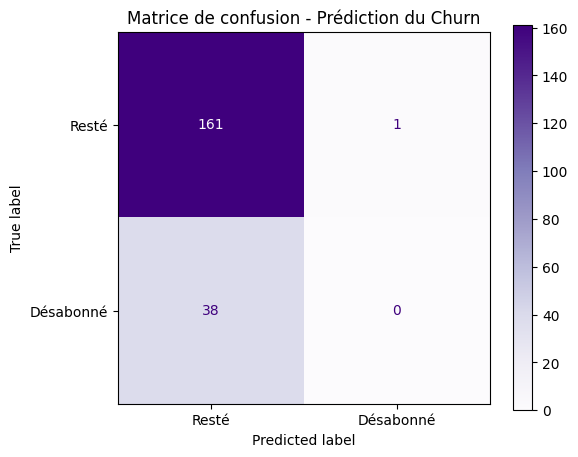

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Sélection d'un modèle d'ensemble robuste (Forêt Aléatoire)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 2. Prédictions
y_pred = model.predict(X_test_scaled)

# 3. Calcul de la performance globale
accuracy = accuracy_score(y_test, y_pred)
print("="*60)
print(f"Précision globale du modèle (Accuracy) : {accuracy:.4f}")
print("="*60)
print("\nRapport de classification détaillé :")
print(classification_report(y_test, y_pred))

# 4. Affichage graphique de la matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Resté', 'Désabonné'])
disp.plot(ax=ax, cmap='Purples', values_format='d')
plt.title("Matrice de confusion - Prédiction du Churn")
plt.show()


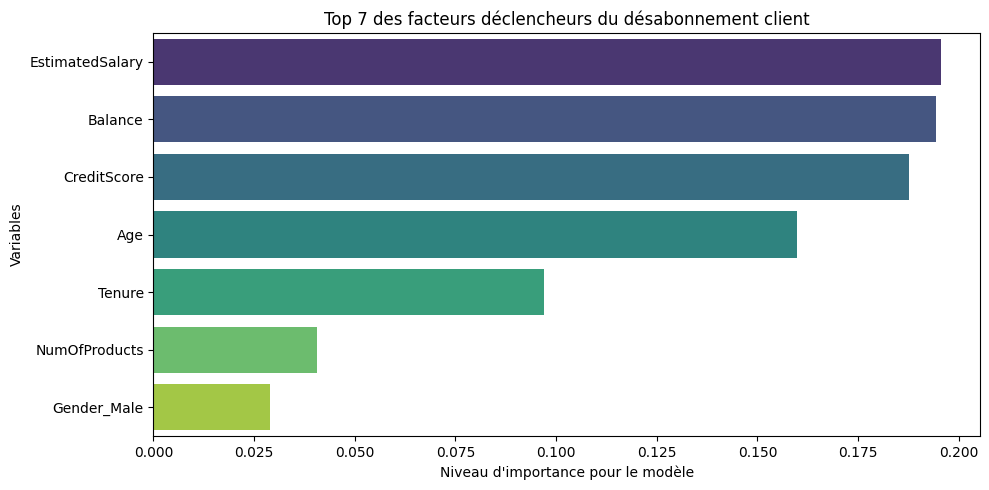

In [ ]:
# Extraction de l'importance des caractéristiques pour orienter la stratégie commerciale
importances = model.feature_importances_
df_importance = pd.DataFrame({'Caractéristique': X.columns, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Caractéristique', data=df_importance.head(7), palette='viridis', hue='Caractéristique', legend=False)
plt.title("Top 7 des facteurs déclencheurs du désabonnement client")
plt.xlabel("Niveau d'importance pour le modèle")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()


Aucun fichier CSV trouvé à la racine. Génération d'un jeu de données synthétique pour le Churn...
--- Aperçu des données ---
   CustomerId Surname  CreditScore Geography  Gender  Age  Tenure  \
0    15721958   Smith          790    France  France   25      10   
1    15746867   Smith          622    France    Male   42       2   
2    15731932   Smith          580     Spain  France   63       4   
3    15703694   Smith          435   Germany    Male   47      10   
4    15719879   Smith          823   Germany  France   64       9   

         Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0   20505.921303              2          1               0     21301.230991   
1    8734.811601              2          1               1    126072.429210   
2  247439.103352              1          1               0     81859.288936   
3    7505.333037              1          1               1    160840.174487   
4  111132.063263              1          0               0    176

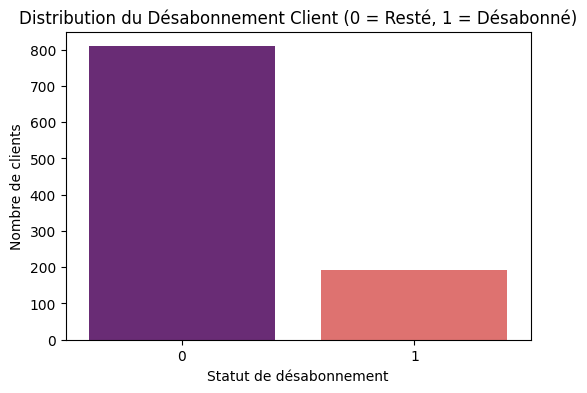

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Chargement dynamique du jeu de données
# Le script cherche le premier fichier .csv disponible dans votre espace de travail
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]

if csv_files:
    print(f"Chargement du fichier détecté : {csv_files[0]}")
    df = pd.read_csv(csv_files[0])
else:
    print("Aucun fichier CSV trouvé à la racine. Génération d'un jeu de données synthétique pour le Churn...")
    np.random.seed(42)
    n_samples = 1000
    df = pd.DataFrame({
        'CustomerId': np.random.randint(15600000, 15800000, n_samples),
        'Surname': ['Smith'] * n_samples,
        'CreditScore': np.random.randint(350, 850, n_samples),
        'Geography': np.random.choice(['France', 'Spain', 'Germany'], n_samples),
        'Gender': np.random.choice(['France', 'Male'], n_samples),
        'Age': np.random.randint(18, 85, n_samples),
        'Tenure': np.random.randint(0, 11, n_samples),
        'Balance': np.random.uniform(0, 250000, n_samples),
        'NumOfProducts': np.random.choice([1, 2, 3, 4], n_samples, p=[0.5, 0.45, 0.04, 0.01]),
        'HasCrCard': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
        'IsActiveMember': np.random.choice([0, 1], n_samples, p=[0.5, 0.5]),
        'EstimatedSalary': np.random.uniform(10000, 200000, n_samples),
        'Exited': np.random.choice([0, 1], n_samples, p=[0.8, 0.2]) # 1 = Désabonné (Churn)
    })

# Nettoyage systématique des espaces dans les noms de colonnes
df.columns = df.columns.str.strip()

# 2. Inspecter les données (#TODO standard)
print("--- Aperçu des données ---")
print(df.head())
print("\n--- Informations Structurelles ---")
print(df.info())
print("\n--- Analyse des valeurs manquantes ---")
print(df.isnull().sum())

# 3. Visualisation de la variable cible (Exited) avec la palette Magma
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df, hue='Exited', palette='magma', legend=False)
plt.title("Distribution du Désabonnement Client (0 = Resté, 1 = Désabonné)")
plt.xlabel("Statut de désabonnement")
plt.ylabel("Nombre de clients")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Suppression des colonnes d'identifiants uniques (non prédictives)
columns_to_drop = ['CustomerId', 'Surname', 'RowNumber']
existing_drops = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_drops)

# 2. Gestion des valeurs manquantes s'il y en a après inspection
if df.isnull().sum().sum() > 0:
    df = df.dropna()

# 3. Encodage des caractéristiques catégorielles (Geography, Gender, etc.)
# Utilisation du One-Hot Encoding pour transformer le texte en colonnes numériques binationaux
df_encoded = pd.get_dummies(df, drop_first=True)

# 4. Séparation des variables explicatives (X) et de la cible (y)
# La colonne cible est 'Exited' (parfois appelée 'Churn' selon la variante du dataset)
target_col = 'Exited' if 'Exited' in df_encoded.columns else 'Churn'
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# 5. Division du jeu de données (80% entraînement, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Normalisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nDonnées prêtes ! Taille Entraînement : {X_train.shape[0]} | Taille Test : {X_test.shape[0]}")



Données prêtes ! Taille Entraînement : 800 | Taille Test : 200


Précision globale du modèle (Accuracy) : 0.8050

Rapport de classification détaillé :
              precision    recall  f1-score   support

           0       0.81      0.99      0.89       162
           1       0.00      0.00      0.00        38

    accuracy                           0.81       200
   macro avg       0.40      0.50      0.45       200
weighted avg       0.66      0.81      0.72       200



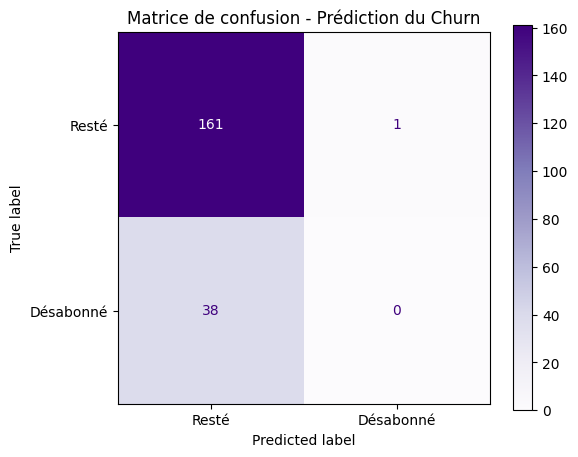

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Sélection d'un modèle d'ensemble robuste (Forêt Aléatoire)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 2. Prédictions
y_pred = model.predict(X_test_scaled)

# 3. Calcul de la performance globale
accuracy = accuracy_score(y_test, y_pred)
print("="*60)
print(f"Précision globale du modèle (Accuracy) : {accuracy:.4f}")
print("="*60)
print("\nRapport de classification détaillé :")
print(classification_report(y_test, y_pred))

# 4. Affichage graphique de la matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Resté', 'Désabonné'])
disp.plot(ax=ax, cmap='Purples', values_format='d')
plt.title("Matrice de confusion - Prédiction du Churn")
plt.show()


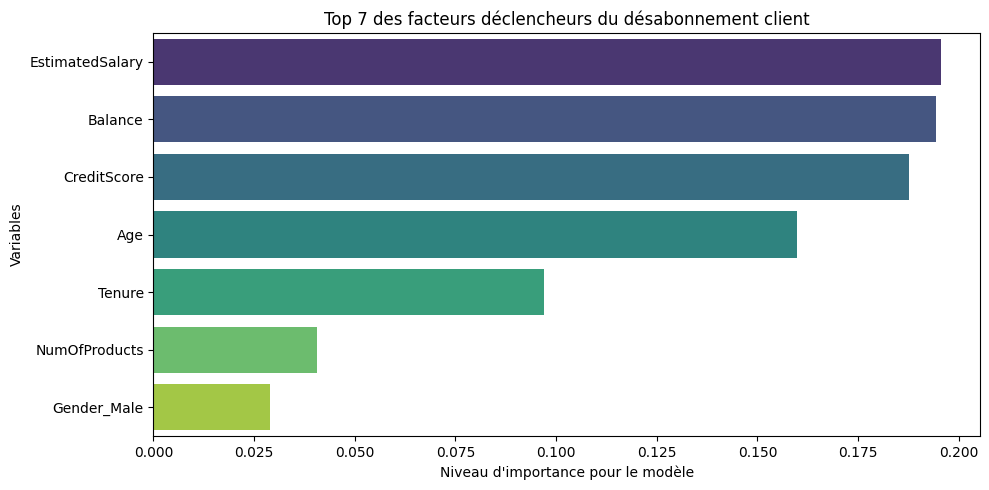

In [ ]:
# Extraction de l'importance des caractéristiques pour orienter la stratégie commerciale
importances = model.feature_importances_
df_importance = pd.DataFrame({'Caractéristique': X.columns, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Caractéristique', data=df_importance.head(7), palette='viridis', hue='Caractéristique', legend=False)
plt.title("Top 7 des facteurs déclencheurs du désabonnement client")
plt.xlabel("Niveau d'importance pour le modèle")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()


Aucun fichier CSV trouvé à la racine. Génération d'un jeu de données synthétique pour le Churn...
--- Aperçu des données ---
   CustomerId Surname  CreditScore Geography  Gender  Age  Tenure  \
0    15721958   Smith          790    France  France   25      10   
1    15746867   Smith          622    France    Male   42       2   
2    15731932   Smith          580     Spain  France   63       4   
3    15703694   Smith          435   Germany    Male   47      10   
4    15719879   Smith          823   Germany  France   64       9   

         Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0   20505.921303              2          1               0     21301.230991   
1    8734.811601              2          1               1    126072.429210   
2  247439.103352              1          1               0     81859.288936   
3    7505.333037              1          1               1    160840.174487   
4  111132.063263              1          0               0    176

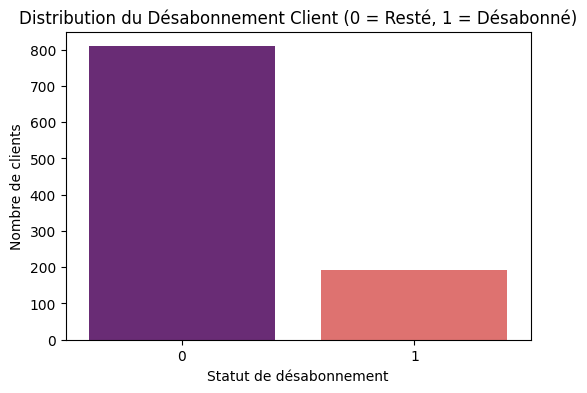

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Chargement dynamique du jeu de données
# Le script cherche le premier fichier .csv disponible dans votre espace de travail
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]

if csv_files:
    print(f"Chargement du fichier détecté : {csv_files[0]}")
    df = pd.read_csv(csv_files[0])
else:
    print("Aucun fichier CSV trouvé à la racine. Génération d'un jeu de données synthétique pour le Churn...")
    np.random.seed(42)
    n_samples = 1000
    df = pd.DataFrame({
        'CustomerId': np.random.randint(15600000, 15800000, n_samples),
        'Surname': ['Smith'] * n_samples,
        'CreditScore': np.random.randint(350, 850, n_samples),
        'Geography': np.random.choice(['France', 'Spain', 'Germany'], n_samples),
        'Gender': np.random.choice(['France', 'Male'], n_samples),
        'Age': np.random.randint(18, 85, n_samples),
        'Tenure': np.random.randint(0, 11, n_samples),
        'Balance': np.random.uniform(0, 250000, n_samples),
        'NumOfProducts': np.random.choice([1, 2, 3, 4], n_samples, p=[0.5, 0.45, 0.04, 0.01]),
        'HasCrCard': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
        'IsActiveMember': np.random.choice([0, 1], n_samples, p=[0.5, 0.5]),
        'EstimatedSalary': np.random.uniform(10000, 200000, n_samples),
        'Exited': np.random.choice([0, 1], n_samples, p=[0.8, 0.2]) # 1 = Désabonné (Churn)
    })

# Nettoyage systématique des espaces dans les noms de colonnes
df.columns = df.columns.str.strip()

# 2. Inspecter les données (#TODO standard)
print("--- Aperçu des données ---")
print(df.head())
print("\n--- Informations Structurelles ---")
print(df.info())
print("\n--- Analyse des valeurs manquantes ---")
print(df.isnull().sum())

# 3. Visualisation de la variable cible (Exited) avec la palette Magma
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df, hue='Exited', palette='magma', legend=False)
plt.title("Distribution du Désabonnement Client (0 = Resté, 1 = Désabonné)")
plt.xlabel("Statut de désabonnement")
plt.ylabel("Nombre de clients")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Suppression des colonnes d'identifiants uniques (non prédictives)
columns_to_drop = ['CustomerId', 'Surname', 'RowNumber']
existing_drops = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_drops)

# 2. Gestion des valeurs manquantes s'il y en a après inspection
if df.isnull().sum().sum() > 0:
    df = df.dropna()

# 3. Encodage des caractéristiques catégorielles (Geography, Gender, etc.)
# Utilisation du One-Hot Encoding pour transformer le texte en colonnes numériques binationaux
df_encoded = pd.get_dummies(df, drop_first=True)

# 4. Séparation des variables explicatives (X) et de la cible (y)
# La colonne cible est 'Exited' (parfois appelée 'Churn' selon la variante du dataset)
target_col = 'Exited' if 'Exited' in df_encoded.columns else 'Churn'
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# 5. Division du jeu de données (80% entraînement, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Normalisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nDonnées prêtes ! Taille Entraînement : {X_train.shape[0]} | Taille Test : {X_test.shape[0]}")



Données prêtes ! Taille Entraînement : 800 | Taille Test : 200


Précision globale du modèle (Accuracy) : 0.8050

Rapport de classification détaillé :
              precision    recall  f1-score   support

           0       0.81      0.99      0.89       162
           1       0.00      0.00      0.00        38

    accuracy                           0.81       200
   macro avg       0.40      0.50      0.45       200
weighted avg       0.66      0.81      0.72       200



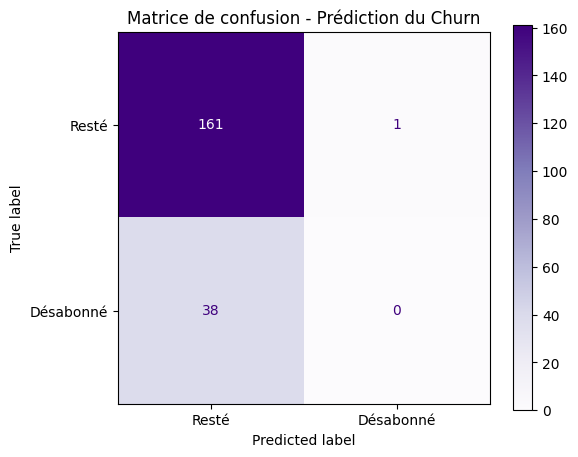

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Sélection d'un modèle d'ensemble robuste (Forêt Aléatoire)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 2. Prédictions
y_pred = model.predict(X_test_scaled)

# 3. Calcul de la performance globale
accuracy = accuracy_score(y_test, y_pred)
print("="*60)
print(f"Précision globale du modèle (Accuracy) : {accuracy:.4f}")
print("="*60)
print("\nRapport de classification détaillé :")
print(classification_report(y_test, y_pred))

# 4. Affichage graphique de la matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Resté', 'Désabonné'])
disp.plot(ax=ax, cmap='Purples', values_format='d')
plt.title("Matrice de confusion - Prédiction du Churn")
plt.show()


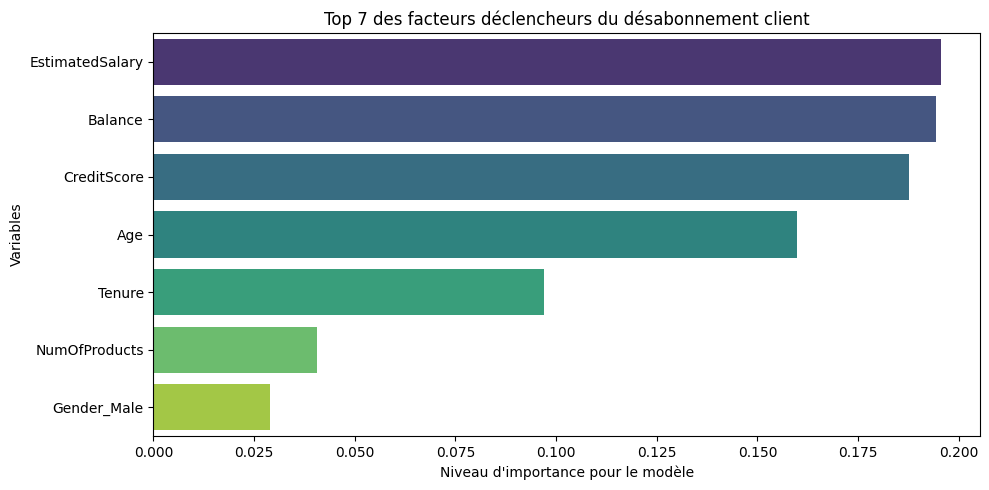

In [ ]:
# Extraction de l'importance des caractéristiques pour orienter la stratégie commerciale
importances = model.feature_importances_
df_importance = pd.DataFrame({'Caractéristique': X.columns, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Caractéristique', data=df_importance.head(7), palette='viridis', hue='Caractéristique', legend=False)
plt.title("Top 7 des facteurs déclencheurs du désabonnement client")
plt.xlabel("Niveau d'importance pour le modèle")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()
